# Gibbs Sampling from Factor Graphs
---

In [6]:
%load_ext autoreload
%autoreload 2
%aimport fac_graphs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Define a simple factor graph

Here we'll create a simple factor graph with three variables and two factors composed of Discrete Neural Network EBMs. Each DiscreteNNEBM will have a depth of one with three hidden nodes.

In [7]:
from fac_graphs.models.factor_graphs import FactorGraph, VariableNode, FactorNode
from fac_graphs.graph_utils import draw_graph
from fac_graphs.inference.gibbs_sampling import GibbsSampler
from energax.ebms.nn_ebms import DiscreteNNEBM
from energax.sampling.discrete import DiscreteUniformMH
import equinox as eqx
import jax
import jax.numpy as jnp
from jaxtyping import Int, Array, PRNGKeyArray
import matplotlib.pyplot as plt

from typing import List

key = jax.random.PRNGKey(42)

### Create three discrete variables

In [8]:
variables = [VariableNode(name=f"x{i}") for i in range(3)]

### Create the underlying equinox neural network

In [9]:
class SimpleNeuralNetwork(eqx.Module):
    layers: List[eqx.Module]

    def __init__(self, key: PRNGKeyArray, dim: int = 2, hidden_features: int = 3):
        """Initialize the neural network."""
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(dim, hidden_features, key=keys[0]),
            eqx.nn.Linear(hidden_features, hidden_features, key=keys[1]),
            eqx.nn.Linear(hidden_features, 1, key=keys[2]),
        ]

    def __call__(self, x: Int[Array, ""]) -> Int[Array, ""]:
        """Compute the output of the neural network."""
        for layer in self.layers[:-1]:
            x = jax.nn.sigmoid(layer(x))
        return jnp.squeeze(self.layers[-1](x))

### Create two factors

In [10]:
key, subkey = jax.random.split(key)
nn_1 = DiscreteNNEBM(nn=SimpleNeuralNetwork(key=subkey))

key, subkey = jax.random.split(key)
nn_2 = DiscreteNNEBM(nn=SimpleNeuralNetwork(key=subkey))

factor_1 = FactorNode([variables[0], variables[1]], factor=nn_1, name="f1")
factor_2 = FactorNode([variables[1], variables[2]], factor=nn_2, name="f2")

### Construct the Factor Graph

<Figure size 400x400 with 0 Axes>

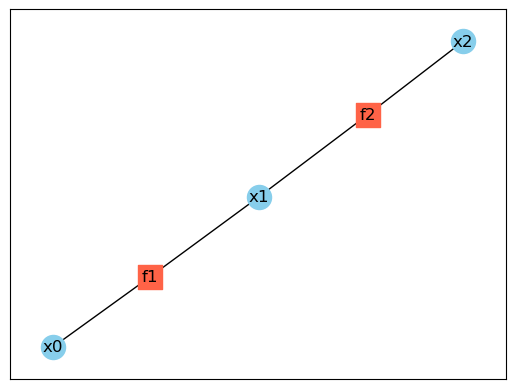

In [11]:
g = FactorGraph([factor_1, factor_2])

plt.figure(figsize=(4, 4))
draw_graph(g)

## Perform Gibbs Sampling

In [12]:
x0 = variables[0]
x1 = variables[1]
x2 = variables[2]

sampler = DiscreteUniformMH(
    xshape=(1,),
    burn_in_steps=100,
    chain_steps=1,
    num_chains=10,
)

vals = {x0: jnp.array([0]), x1: jnp.array([0]), x2: jnp.array([1])}
samps = {x0: sampler, x1: sampler, x2: sampler}
num_chains = 10
repetitions = 1
gibbs_sampler = GibbsSampler(
    samps,
    num_chains=num_chains,
    reps=repetitions,
    traversal_order=[x0, x1, x2],
    squeeze=True,
)

## Sample a single variable with all the others fixed to their initial value

In [13]:
gibbs_sampler.sample_single_variable(g, x0, vals, key)

Array([1], dtype=int32)

## Run the Gibbs Sampler for the whole graph

In [14]:
gibbs_sampler.run_chain(g, vals, key)

{VariableNode(name='x0'): Array([1], dtype=int32),
 VariableNode(name='x1'): Array([1], dtype=int32),
 VariableNode(name='x2'): Array([1], dtype=int32)}

## Run the Gibbs sampler many times in parallel

The number of samples corresponds to the `num_chains` defined at the initialization of the GibbsSampler object.

Note that in this case the Gibbs sampler starts from the same initial value given by `vals` for each sample.

In [15]:
gibbs_sampler.sample_chains(g, vals, key)

{VariableNode(name='x0'): Array([[1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [0]], dtype=int32),
 VariableNode(name='x1'): Array([[1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [1],
        [0]], dtype=int32),
 VariableNode(name='x2'): Array([[0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [1]], dtype=int32)}

#### Use different starting values for each sample

To use a different starting value for each sample, we can pass a list of initial values to the `vals` argument and vmap it.

In [16]:
def random_starting_state(
    key: PRNGKeyArray, num_chains: int, variables: List[VariableNode]
) -> dict:
    keys = jax.random.split(key, len(variables))
    return {
        v: jax.random.randint(keys[i], shape=(num_chains, 1), minval=0, maxval=2)
        for i, v in enumerate(variables)
    }


key2, subkey = jax.random.split(key)
vals_batch = random_starting_state(key2, num_chains, variables)
keys = jax.random.split(key, num_chains)
eqx.filter_vmap(gibbs_sampler.run_chain, in_axes=(None, 0, 0))(g, vals_batch, keys)

{VariableNode(name='x0'): Array([[1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [0]], dtype=int32),
 VariableNode(name='x1'): Array([[1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [1],
        [0]], dtype=int32),
 VariableNode(name='x2'): Array([[0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [1]], dtype=int32)}